In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
#Importation des librairies
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import chi2_contingency, pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from pandas.plotting import scatter_matrix
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.impute import SimpleImputer



In [77]:
#Importation du billets .csv
billets = pd.read_csv("billets.csv", sep=';')


billets_faux = billets[billets["is_genuine"] == False]
billets_vrais = billets[billets["is_genuine"] == True]

billets_faux = billets_faux.reset_index(drop=True)
billets_vrais = billets_vrais.reset_index(drop=True)


# Colonnes numériques
colonnes = ["diagonal", "height_left", "height_right",
            "margin_low", "margin_up", "length"]


In [78]:
billets.describe()


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [79]:
billets_faux.describe()


,diagonal,height_left,height_right,margin_low,margin_up,length
count,500.000000,500.000000,500.000000,492.000000,500.000000,500.000000
mean,171.901160,104.190340,104.143620,5.215935,3.350160,111.630640
std,0.306861,0.223758,0.270878,0.553531,0.180498,0.615543
min,171.040000,103.510000,103.430000,3.820000,2.920000,109.490000
25%,171.690000,104.040000,103.950000,4.840000,3.220000,111.200000
50%,171.910000,104.180000,104.160000,5.190000,3.350000,111.630000
75%,172.092500,104.332500,104.320000,5.592500,3.472500,112.030000
max,173.010000,104.880000,104.950000,6.900000,3.910000,113.850000


In [80]:
billets_vrais.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1000.000000,1000.000000,1000.00000,971.000000,1000.00000,1000.000000
mean,171.987080,103.949130,103.80865,4.116097,3.05213,113.202430
std,0.300441,0.300231,0.29157,0.319124,0.18634,0.359552
min,171.040000,103.140000,102.82000,2.980000,2.27000,111.760000
25%,171.790000,103.740000,103.61000,3.905000,2.93000,112.950000
50%,171.990000,103.950000,103.81000,4.110000,3.05000,113.205000
75%,172.200000,104.140000,104.00000,4.340000,3.18000,113.460000
max,172.920000,104.860000,104.95000,5.040000,3.74000,114.440000


In [81]:
#Code pour analyser les nulls

In [82]:
billets.isnull().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0


In [83]:
billets_faux.isnull().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,8
margin_up,0
length,0


In [84]:
billets_vrais.isnull().sum()

,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,29
margin_up,0
length,0


In [85]:
#PART 2 - Gestion des nuls et analyse

In [86]:
#Définition des DF - enlever les null OU imputer séparement les vrais et faux avec une médiane des chacun - imputer ensemble des vrais faux sans distinction avec l'aide d'une médiane commun

#Billets suppression des nulls
billets_drop_null = billets.dropna()

#Billets imputés ensemble
billets_median_global = billets_median_global = billets.copy()
billets_median_global[colonnes] = billets_median_global[colonnes].fillna(
    billets_median_global[colonnes].median()
)

#Billets imputés séparement
billets_vrais["margin_low"] = billets_vrais["margin_low"].fillna(
    billets_vrais["margin_low"].median()
)

billets_faux["margin_low"] = billets_faux["margin_low"].fillna(
    billets_faux["margin_low"].median()
)

billets_imputed = pd.concat([billets_vrais, billets_faux], axis=0, ignore_index=True)

billets_imputed_separated = billets_imputed



In [87]:
#Paramétrage Imputation
df = billets_drop_null
#df = billets_imputed_separated
#df = billets_median_global



In [88]:
#Nouvelles analyse du nouveau df avec suppression des nulls
df_faux = df[df["is_genuine"] == False]

df_vrais = df[df["is_genuine"] == True]



In [89]:
df_faux.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000
mean,171.901402,104.188537,104.143272,5.215935,3.351504,111.632114
std,0.305473,0.224418,0.271683,0.553531,0.179343,0.615343
min,171.040000,103.510000,103.430000,3.820000,2.920000,109.490000
25%,171.697500,104.040000,103.950000,4.840000,3.227500,111.200000
50%,171.910000,104.180000,104.160000,5.190000,3.350000,111.630000
75%,172.092500,104.330000,104.320000,5.592500,3.472500,112.030000
max,173.010000,104.880000,104.950000,6.900000,3.910000,113.850000


In [90]:
df_vrais.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,971.000000,971.000000,971.000000,971.000000,971.000000,971.000000
mean,171.988476,103.951679,103.809094,4.116097,3.052544,113.203059
std,0.301402,0.301518,0.288862,0.319124,0.185425,0.356123
min,171.040000,103.140000,102.910000,2.980000,2.270000,111.760000
25%,171.790000,103.745000,103.610000,3.905000,2.925000,112.960000
50%,171.990000,103.950000,103.810000,4.110000,3.050000,113.200000
75%,172.200000,104.140000,104.000000,4.340000,3.180000,113.460000
max,172.920000,104.860000,104.950000,5.040000,3.740000,114.320000


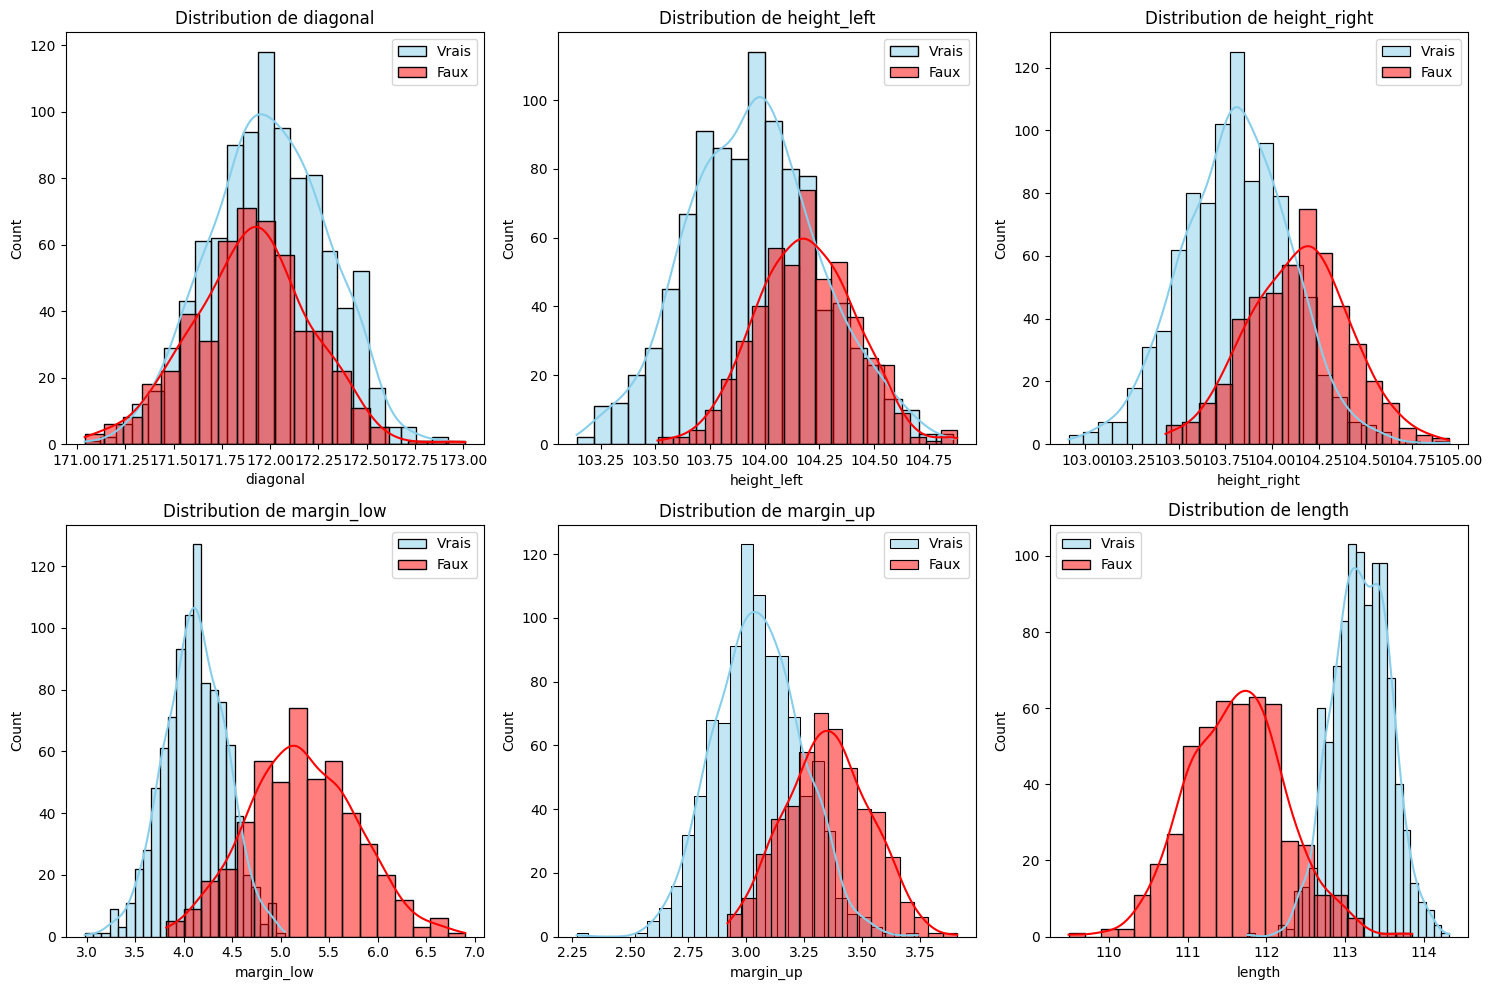

In [91]:
#exclusion car on cherche à analyser les autres colonnes
df_col = df.columns.drop('is_genuine')

#Histos
plt.figure(figsize=(15, 10))
for i, col in enumerate(df_col, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[df['is_genuine'] == True][col], color="skyblue", label='Vrais', kde=True)
    sns.histplot(df[df['is_genuine'] == False][col], color="red", label='Faux', kde=True)
    plt.title(f'Distribution de {col}')
    plt.legend()
plt.tight_layout()
plt.show()



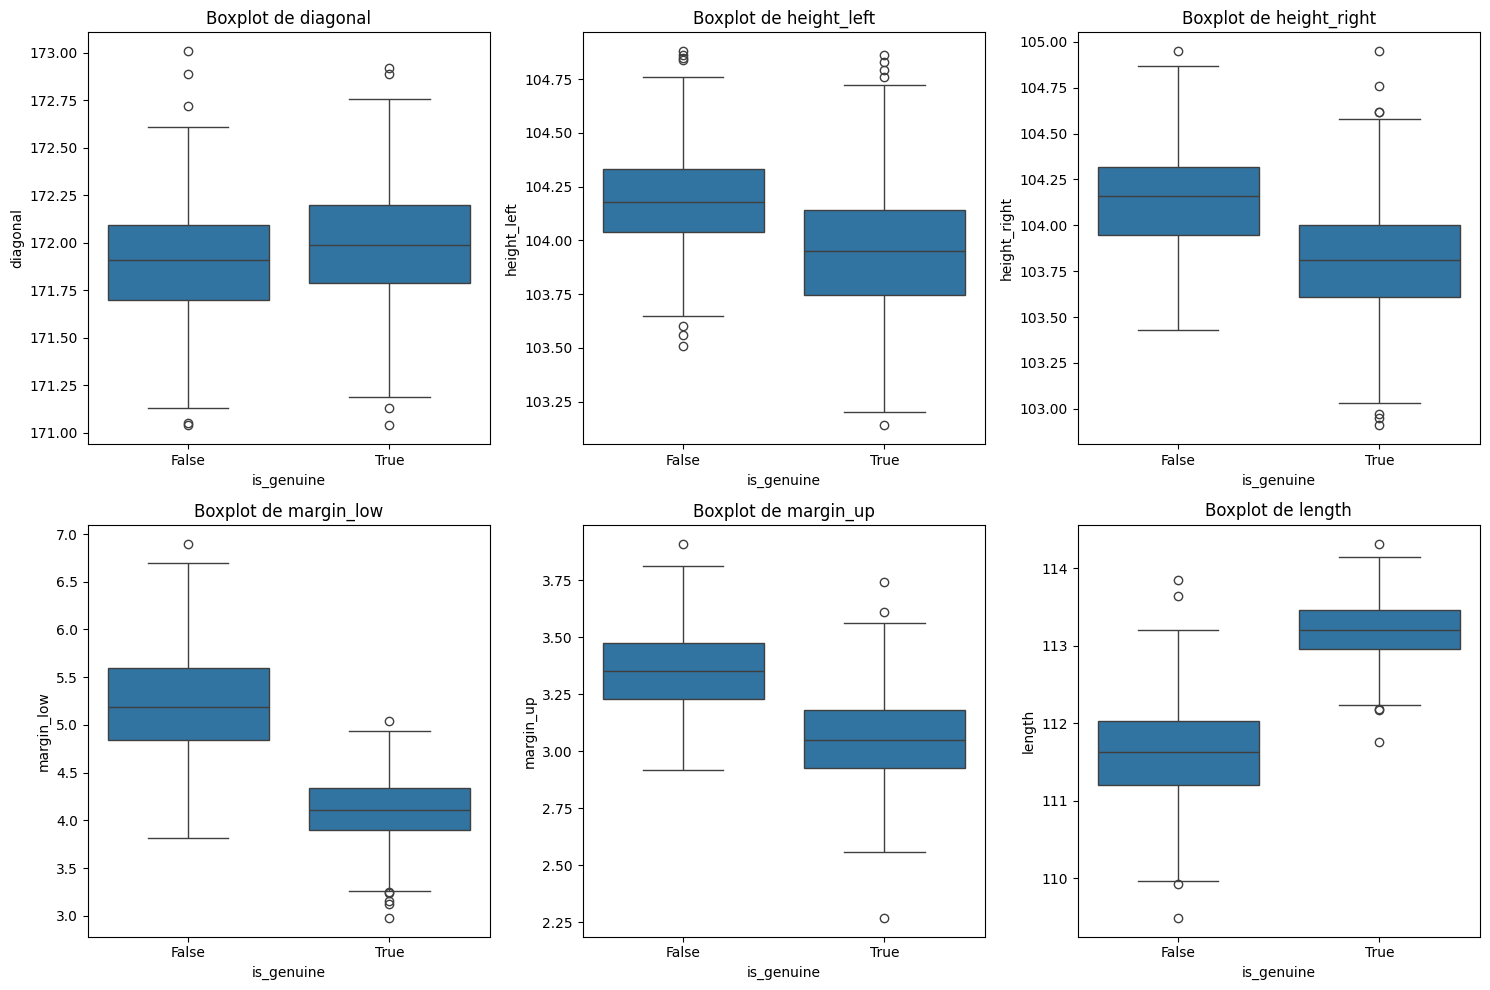

In [92]:
#Boites à moustache
plt.figure(figsize=(15, 10))
for i, col in enumerate(df_col, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='is_genuine', y=col, data=df)
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

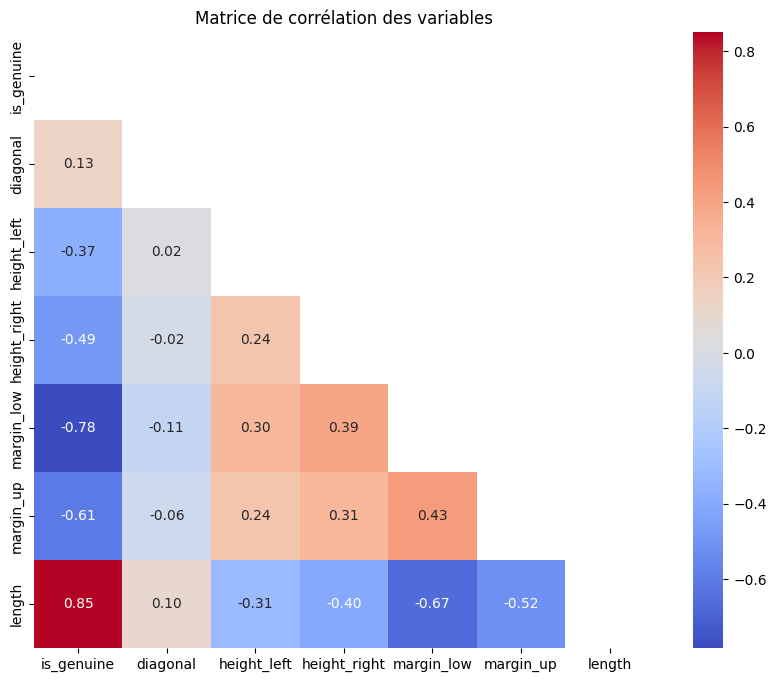

In [93]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation des variables")
plt.show()

In [94]:
#Paramétrage train split
TEST_SIZE = 0.2     #Sur 1500 lignes c'est ok cela laisse assez de données en entrainement mais aussi assez de données restantes en test
RANDOM_STATE = 42
STRATIFY = True


In [95]:
#Code train split

colonnes = ['diagonal', 'height_left', 'height_right',
            'margin_low', 'margin_up', 'length']

X = df[colonnes]
y = df['is_genuine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y if STRATIFY else None
)



In [96]:
#Normalisation scaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=colonnes, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=colonnes, index=X_test.index)


In [97]:
import statsmodels.api as sm

#Check variable utiles en fonction de leur p value pour voir si elle ont un role dans la detection d'un vrai ou faux billet
X_ols = sm.add_constant(X_train_scaled)
y_ols = y_train.values

modele_ols = sm.OLS(y_ols, X_ols).fit()

print(modele_ols.pvalues.round(4))

const           0.0000
diagonal        0.0049
height_left     0.0000
height_right    0.0000
margin_low      0.0000
margin_up       0.0000
length          0.0000
dtype: float64


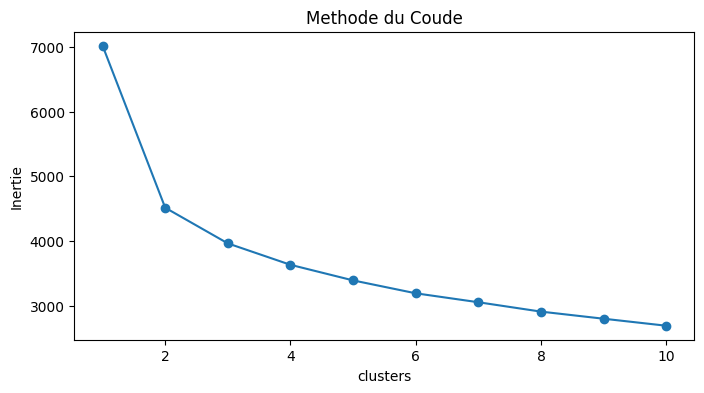

In [98]:
#Coude sur 10
interties = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)

    interties.append(km.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), interties, marker='o')
plt.title("Methode du Coude")
plt.xlabel("clusters")
plt.ylabel("Inertie")
plt.show()

In [99]:

#Kmeans
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_train_scaled)

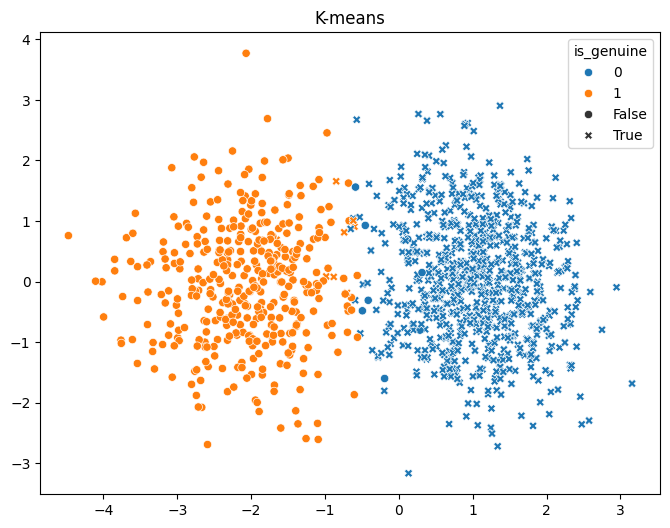

In [100]:
#ACP avec projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, style=y_train)
plt.title("K-means")
plt.show()

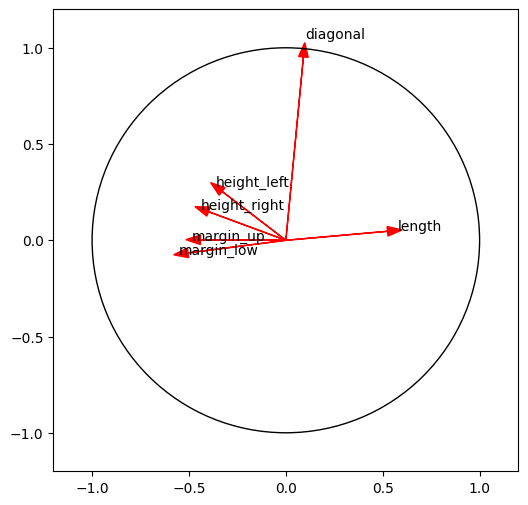

In [101]:
#Cercle correlation

plt.figure(figsize=(6, 6))

for i, col in enumerate(colonnes):
    plt.arrow(0, 0, pca.components_[0, i], pca.components_[1, i], head_width=0.05, color='r')
    plt.text(pca.components_[0, i]*1.1, pca.components_[1, i]*1.1, col)

plt.gca().add_artist(plt.Circle((0,0), 1, fill=False))
plt.xlim(-1.2, 1.2); plt.ylim(-1.2, 1.2)
plt.show()

In [102]:
X_train_final = X_train_scaled[colonnes]
X_test_final = X_test_scaled[colonnes]

#K-MEANS
kmeans_billets = km_final.predict(X_test_final)

if (kmeans_billets == y_test).mean() < 0.5:
    kmeans_billets = 1 - kmeans_billets

score_km = (kmeans_billets == y_test).mean()
print(f"Score K-means : {score_km:.2%}")


#RÉGRESSION LOGISTIQUE
log_reg = LogisticRegression(random_state=RANDOM_STATE)
log_reg.fit(X_train_final, y_train)
score_log = log_reg.score(X_test_final, y_test)
print(f"Score Régression Logistique : {score_log:.2%}")

#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_final, y_train)
score_knn = knn.score(X_test_final, y_test)
print(f"Score KNN : {score_knn:.2%}")

#RANDOM FOREST
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train_final, y_train)
score_rf = rf.score(X_test_final, y_test)
print(f"Score Random Forest : {score_rf:.2%}")

Score K-means : 97.95%
Score Régression Logistique : 98.98%
Score KNN : 98.29%
Score Random Forest : 98.98%


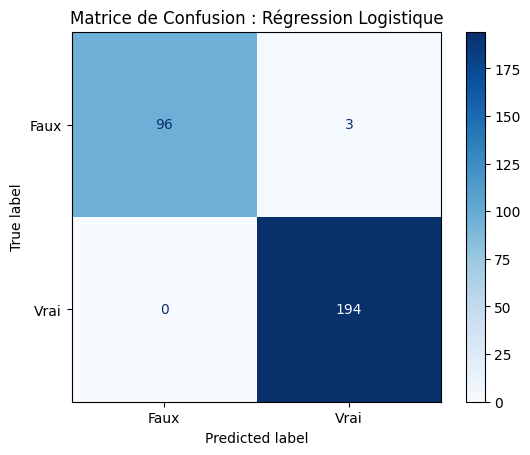

Accuracy : 98.98%


In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

#entrainement du modèle sur les données sélectionnées par OLS
log_reg = LogisticRegression(random_state=RANDOM_STATE)
log_reg.fit(X_train_final, y_train)

#prediction
y_pred = log_reg.predict(X_test_final)

#matrice
cm = confusion_matrix(y_test, y_pred)

#visu
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Faux', 'Vrai'])
disp.plot(cmap='Blues')
plt.title("Matrice de Confusion : Régression Logistique")
plt.show()


print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")

In [104]:
#Check des erreurs pour voir ce qui pose problème
y_pred = log_reg.predict(X_test_final)
erreurs_idx = (y_test != y_pred)

if erreurs_idx.any():
    print(f"{erreurs_idx.sum()} erreurs")

    df_erreurs = X_test.loc[erreurs_idx].copy()
    df_erreurs['Ce qui devrait être prédit (le vrai is genuine)'] = y_test[erreurs_idx]
    df_erreurs['Prédiction avec notre modèle'] = y_pred[erreurs_idx]

    print("Erreurs")
    print(df_erreurs)
else:
    print("")

3 erreurs
Erreurs
      diagonal  height_left  height_right  margin_low  margin_up  length  \
1103    171.88       104.05        103.75        4.41       3.21  112.52   
1407    172.02       103.99        104.28        4.22       2.98  112.42   
1190    171.45       104.21        104.18        4.55       3.52  113.21   

      Ce qui devrait être prédit (le vrai is genuine)  \
1103                                            False   
1407                                            False   
1190                                            False   

      Prédiction avec notre modèle  
1103                          True  
1407                          True  
1190                          True  


In [105]:
import joblib

joblib.dump(log_reg, 'Model_Final.pkl')


['Model_Final.pkl']

In [106]:
joblib.dump(scaler, 'Scaler.pkl')

['Scaler.pkl']